Epoch 1/50


d:\Program Files\Python\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0338 - val_loss: 0.0028
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0043 - val_loss: 0.0032
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0039 - val_loss: 0.0020
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0052 - val_loss: 0.0018
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0035 - val_loss: 0.0021
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0030 - val_loss: 0.0018
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0028 - val_l

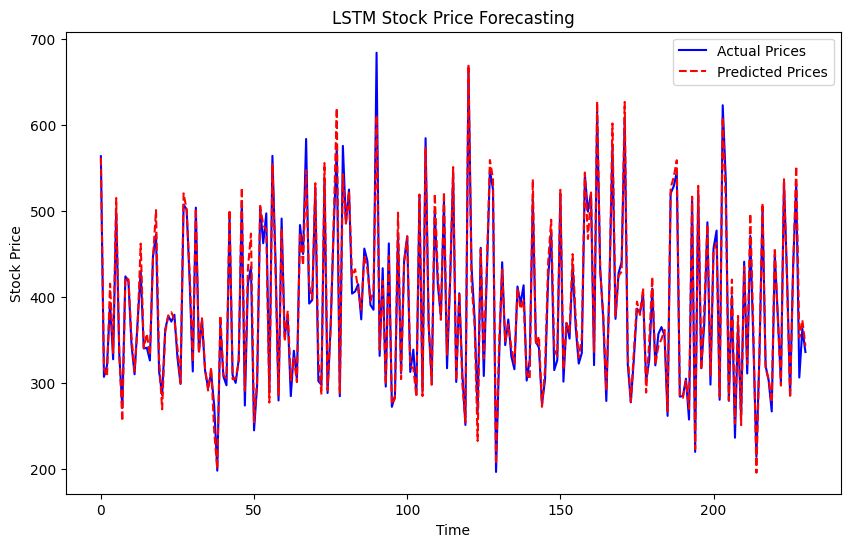

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# --- Load Stock Data ---
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0700_cleaned.xlsx"
df = pd.read_excel(file_path)

# --- Select Close Price for Forecasting ---
data = df[["Close"]].values

# --- Normalize Data (Scaling between 0 and 1) ---
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# --- Create Data Sequences for LSTM ---
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])  # Past 'seq_length' days
        y.append(data[i + seq_length])    # Next day's price
    return np.array(X), np.array(y)

seq_length = 30  # Using past 30 days to predict the next day
X, y = create_sequences(data_scaled, seq_length)

# --- Split Data into Training & Test Sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Build LSTM Model ---
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)  # Single output: predicted close price
])

# --- Compile Model ---
model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error")

# --- Train Model ---
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# --- Make Predictions ---
y_pred = model.predict(X_test)

# --- Reverse Scaling to Get Actual Price Predictions ---
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred)

# --- Plot Predictions vs. Actual Prices ---
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label="Actual Prices", color="blue")
plt.plot(y_pred_actual, label="Predicted Prices", color="red", linestyle="dashed")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("LSTM Stock Price Forecasting")
plt.legend()
plt.show()


Epoch 1/50


d:\Program Files\Python\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0397
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0042
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0026
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0020
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0021
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021
Epoch 13/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025
Epoch 14/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0021
Epoch 15/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022
Epoch 16/50
72/

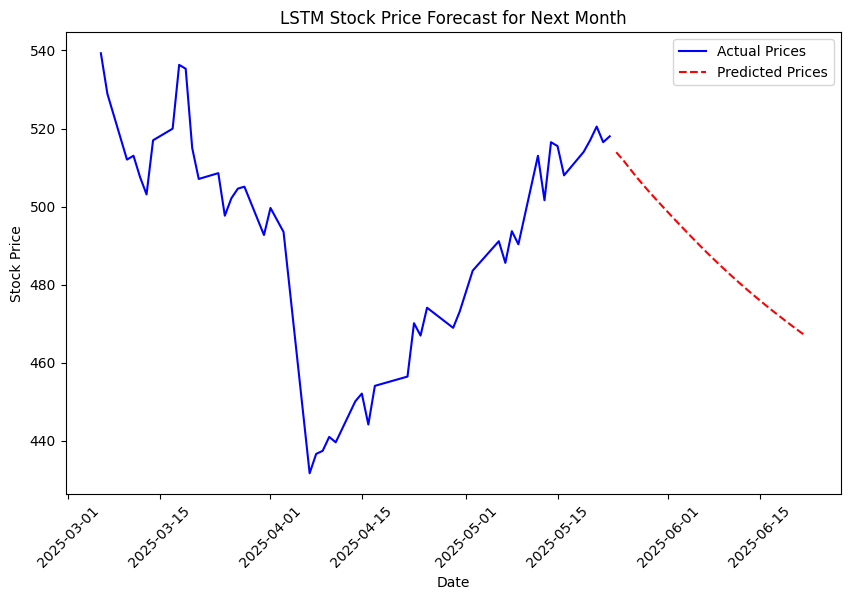

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# --- Load Stock Data ---
file_path = r"D:\Steven Documents\Project\HK options stock analysis\Stock data\0700_cleaned.xlsx"
df = pd.read_excel(file_path)

# --- Convert Date Column to Datetime Format ---
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)  # Ensure Date is the index

# --- Select Close Price for Forecasting ---
data = df[["Close"]].values

# --- Normalize Data (Scaling between 0 and 1) ---
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# --- Create Sequences for LSTM ---
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])  # Past 'seq_length' days
        y.append(data[i + seq_length])    # Next day's price
    return np.array(X), np.array(y)

seq_length = 30  # Using past 30 days to predict the next day
X, y = create_sequences(data_scaled, seq_length)

# --- Reshape Data for LSTM ---
X = X.reshape(X.shape[0], X.shape[1], 1)

# --- Train LSTM Model ---
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)  # Output: predicted close price
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error")
model.fit(X, y, epochs=50, batch_size=16, verbose=1)

# --- Forecast Next 30 Days ---
last_seq = X[-1]  # Last known sequence for prediction
predictions = []

for _ in range(30):  # Predicting next 30 days
    pred_price = model.predict(last_seq.reshape(1, seq_length, 1))[0][0]
    predictions.append(pred_price)
    last_seq = np.append(last_seq[1:], pred_price).reshape(seq_length, 1)  # Update sequence

# --- Reverse Scaling to Get Actual Prices ---
predictions_actual = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# --- Create a DataFrame for Predictions ---
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30, freq="D")
forecast_df = pd.DataFrame({"Date": future_dates, "Predicted_Close": predictions_actual.flatten()})

print("\nNext Month's Stock Price Forecast:")
print(forecast_df)

# --- Plot Future Price Predictions ---
plt.figure(figsize=(10, 6))
plt.plot(df.index[-50:], df["Close"].iloc[-50:], label="Actual Prices", color="blue")  # Last 50 days
plt.plot(future_dates, predictions_actual, label="Predicted Prices", color="red", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("LSTM Stock Price Forecast for Next Month")
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# --- Reverse Scaling (Convert Predictions & Actual Prices Back to Original Scale) ---
y_test_actual = scaler.inverse_transform(y.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(model.predict(X))

# --- Calculate R² Score ---
r2 = r2_score(y_test_actual, y_pred_actual)
print(f"\nR² Score (Explained Variance): {r2:.4f}")

# --- Calculate Mean Squared Error (MSE) ---
mse = mean_squared_error(y_test_actual, y_pred_actual)
print(f"Mean Squared Error (MSE): {mse:.4f}")


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

R² Score (Explained Variance): 0.9946
Mean Squared Error (MSE): 1.3226
